# ライブラリ

In [1]:
# ========================================
# ライブラリの import
# ========================================
# TRT系はコメントアウトされている
import argparse

import torch.onnx
from onnxsim import simplify # onnxグラフの簡略化

from mmcv import Config # Configファイルの読み込み
# from mmdeploy.backend.tensorrt.utils import save, search_cuda_version

# mmdetection/mmdet3d系の読み込み
try:
    # If mmdet version > 2.23.0, compat_cfg would be imported and
    # used from mmdet instead of mmdet3d.
    from mmdet.utils import compat_cfg
except ImportError:
    from mmdet3d.utils import compat_cfg

import os
from typing import Dict, Optional, Sequence, Union

import h5py
import mmcv
import numpy as np
import onnx
# import pycuda.driver as cuda
# import tensorrt as trt
import torch
import tqdm
from mmcv.runner import load_checkpoint
# from mmdeploy.apis.core import no_mp
# from mmdeploy.backend.tensorrt.calib_utils import HDF5Calibrator
# from mmdeploy.backend.tensorrt.init_plugins import load_tensorrt_plugin
# from mmdeploy.utils import load_config
from packaging import version
from torch.utils.data import DataLoader

from mmdet3d.datasets import build_dataloader, build_dataset
from mmdet3d.models import build_model
from mmdet.datasets import replace_ImageToTensor
from tools.misc.fuse_conv_bn import fuse_module

# コマンドライン引数
args = argparse.Namespace(
    config="../configs/fastbev/paper/fastbev-r50-cbgs-4d-custom.py",
    checkpoint="../ckpts/VADHead/epoch_60.pth",
    work_dir="./onnx/",
    prefix="fastbev",
    fp16=False,
    int8=False,
    fuse_conv_bn=False,
)

# オリジナルのモデルの読み込み
# onnxファイルの保存先ディレクトリの作成
if not os.path.exists(args.work_dir):
    os.makedirs(args.work_dir)

# TensorRTプラグイン関連の処理
# load_tensorrt_plugin()
# assert 'bev_pool_v2' in get_plugin_names(), \
#     'bev_pool_v2 is not in the plugin list of tensorrt, ' \
#     'please install mmdeploy from ' \
#     'https://github.com/HuangJunJie2017/mmdeploy.git'

if args.int8:
    assert args.fp16

# 出力モデル名の接頭辞を設定
model_prefix = args.prefix
if args.int8:
    model_prefix = model_prefix + '_int8'
elif args.fp16:
    model_prefix = model_prefix + '_fp16'

# configファイルの読み込み
cfg = Config.fromfile(args.config)

# 事前学習済み重みを読み込まない(後で学習済み重みをloadする)
cfg.model.pretrained = None

# モデル名をTRT用に変更
#cfg.model.type = "FastBEVTRT"

# MMCV系のバージョン互換処理
cfg = compat_cfg(cfg)

# 使用GPUを設定
cfg.gpu_ids = [0]

# データローダーのデフォルト設定
test_dataloader_default_args = dict(samples_per_gpu=1, workers_per_gpu=2, dist=False, shuffle=False)

# データローダーの処理の変更
if isinstance(cfg.data.test, dict):
    cfg.data.test.test_mode = True
    if cfg.data.test_dataloader.get('samples_per_gpu', 1) > 1:
        # Replace 'ImageToTensor' to 'DefaultFormatBundle'
        cfg.data.test.pipeline = replace_ImageToTensor(cfg.data.test.pipeline)
elif isinstance(cfg.data.test, list):
    for ds_cfg in cfg.data.test:
        ds_cfg.test_mode = True
    if cfg.data.test_dataloader.get('samples_per_gpu', 1) > 1:
        for ds_cfg in cfg.data.test:
            ds_cfg.pipeline = replace_ImageToTensor(ds_cfg.pipeline)

# データローダーの作成
test_loader_cfg = {
    **test_dataloader_default_args,
    **cfg.data.get('test_dataloader', {})
}
dataset = build_dataset(cfg.data.test)
data_loader = build_dataloader(dataset, **test_loader_cfg)

# モデルの作成＆重みのロード
cfg.model.train_cfg = None
cfg.model.img_view_transformer.accelerate = True # View変換をTRT用に高速化する
model = build_model(cfg.model, test_cfg=cfg.get('test_cfg'))
load_checkpoint(model, args.checkpoint, map_location='cpu')

# fuse設定
if args.fuse_conv_bn:
    model_prefix = model_prefix + '_fuse'
    model = fuse_module(model)

# 評価モードに設定
model.cuda()
model.eval()

/home/kenta/miniconda3/envs/fastbev/lib/python3.8/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/compatibility.md for more details.
  warnings.warn(


opencv_pp:False


/home/kenta/miniconda3/envs/fastbev/lib/python3.8/site-packages/mmdet/models/backbones/resnet.py:401: UserWarning: DeprecationWarning: pretrained is deprecated, please use "init_cfg" instead
  warnings.warn('DeprecationWarning: pretrained is deprecated, '


load checkpoint from local path: ../ckpts/VADHead/epoch_60.pth


FastBEV4D(
  (pts_bbox_head): VADHead(
    (loss_cls): FocalLoss()
    (loss_bbox): L1Loss()
    (loss_iou): GIoULoss()
    (activate): ReLU(inplace=True)
    (positional_encoding): SinePositionalEncoding(num_feats=128, temperature=10000, normalize=True, scale=6.283185307179586, eps=1e-06)
    (transformer): VADPerceptionTransformer(
      (decoder): DetectionTransformerDecoder(
        (layers): ModuleList(
          (0-2): 3 x DetrTransformerDecoderLayer(
            (attentions): ModuleList(
              (0): MultiheadAttention(
                (attn): MultiheadAttention(
                  (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
                )
                (proj_drop): Dropout(p=0.0, inplace=False)
                (dropout_layer): Dropout(p=0.1, inplace=False)
              )
              (1): CustomMSDeformableAttention(
                (dropout): Dropout(p=0.1, inplace=False)
                (sampling_offsets): Linear(in_fe

# ONNXモデルの設定

In [2]:
# ライブラリ
import numpy as np
import torch
import onnxruntime as ort
import torch.nn.functional as F

from nuscenes_sample_generator import NuScenesSampleGenerator
from img_pipeline import PrepareImageInputs
from onnx_input_builder import OnnxInputBuilder
from bbox_decoder import BboxDecoder
from visualizer import Visualizer 
from util import load_config, load_json

import matplotlib.pyplot as plt

# パスの設定
json_path   = "bevdetv3-nuscenes_infos_val.json"
config_path = "config.yaml"

In [3]:
# jsonファイルとconfigファイルの読み込み
json_file   = load_json(json_path)
data_config = load_config(config_path)

# sample Generator
data_infos = json_file['infos']
sample_generator = NuScenesSampleGenerator(data_infos=data_infos, num_adj_frame=1)

# image pipeline
image_pipline = PrepareImageInputs(data_config["data_config"], sequential=True, opencv_pp=False)

# 入力データの作成
grid_config = data_config["geometry"]["grid_config"]
image_size  = data_config["data_config"]["input_size"]
onnx_input_builder = OnnxInputBuilder(grid_config, image_size, stride=16, accelerate=True)

# モデルの後処理
post_center_range = data_config["bbox_decoder"]["post_center_range"]
max_num           = data_config["bbox_decoder"]["max_num"]
num_classes       = data_config["bbox_decoder"]["num_classes"]
score_threshold   = data_config["bbox_decoder"]["score_threshold"]
bbox_decoder = BboxDecoder(post_center_range, max_num, num_classes, None)

# 可視化
save_path   = data_config["visualizer"]["save_path"]
save_format = data_config["visualizer"]["save_format"]
save_prefix = data_config["visualizer"]["save_prefix"]
fps         = data_config["visualizer"]["fps"]
visualizer  = Visualizer(0.5, save_path, save_format, save_prefix, fps, scale_factor=3, color_map=(0, 255, 255))

# モデルの読み込み
fastbev = ort.InferenceSession(
     "./onnx/fastbev.onnx",
    #providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
    providers=["CPUExecutionProvider"]
)

fastbev4d = ort.InferenceSession(
    "./onnx/fastbev_4d.onnx",
    #providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
    providers=["CPUExecutionProvider"]
)

print("===fastbev===")
print("=== Inputs ===")
for i, x in enumerate(fastbev.get_inputs()):
    print(f"[{i}]")
    print(" name :", x.name)
    print(" shape:", x.shape)
    print(" type :", x.type)

print("\n=== Outputs ===")
for i, x in enumerate(fastbev.get_outputs()):
    print(f"[{i}]")
    print(" name :", x.name)
    print(" shape:", x.shape)
    print(" type :", x.type)

print("\n===fastbev4d===")
print("=== Inputs ===")
for i, x in enumerate(fastbev4d.get_inputs()):
    print(f"[{i}]")
    print(" name :", x.name)
    print(" shape:", x.shape)
    print(" type :", x.type)

print("\n=== Outputs ===")
for i, x in enumerate(fastbev4d.get_outputs()):
    print(f"[{i}]")
    print(" name :", x.name)
    print(" shape:", x.shape)
    print(" type :", x.type)

===fastbev===
=== Inputs ===
[0]
 name : img
 shape: [6, 3, 256, 704]
 type : tensor(float)
[1]
 name : coors_img
 shape: [114688]
 type : tensor(int64)
[2]
 name : coors_depth
 shape: [114688]
 type : tensor(int64)

=== Outputs ===
[0]
 name : bev_feat
 shape: [1, 80, 128, 128]
 type : tensor(float)

===fastbev4d===
=== Inputs ===
[0]
 name : bev_feats
 shape: [1, 160, 128, 128]
 type : tensor(float)

=== Outputs ===
[0]
 name : all_cls_scores
 shape: [1, 300, 10]
 type : tensor(float)
[1]
 name : all_bbox_preds
 shape: [1, 300, 10]
 type : tensor(float)


/home/kenta/fastbev/mmdet3d/datasets/pipelines/loading.py:1307: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1682343998658/work/torch/csrc/utils/tensor_new.cpp:245.)
  gt_boxes, gt_labels = torch.Tensor(gt_boxes), torch.tensor(gt_labels)
/home/kenta/fastbev/mmdet3d/datasets/pipelines/loading.py:1307: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1682343998658/work/torch/csrc/utils/tensor_new.cpp:245.)
  gt_boxes, gt_labels = torch.Tensor(gt_boxes), torch.tensor(gt_labels)
/home/kenta/fastbev/mmdet3d/datasets/pipelines/loading.py:1307: UserWarning: Creating a tensor from a list of numpy.ndarra

rot: [-0.9401876561611837, 0.002165612840875655, -0.001020908817966706, 0.34064855653348847]
trans: [631.5264252466604, 1625.179661478261, 0.0]
rot_quaternion: -0.940 +0.002i -0.001j +0.341k


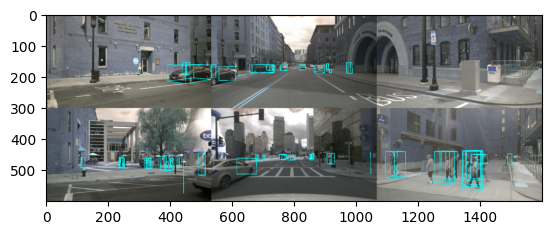

In [24]:
with torch.no_grad():
    for i, data in enumerate(data_loader):            
        if i>=10:
            break
                
        # 入力データを過去と現在フレームに分ける(ONNX)
        input_data = sample_generator.get_data_info(i)
    
        # 前処理
        input_data = image_pipline(input_data)
        imgs_curr2, sensor2keyegos_curr2, ego2globals_curr2, intrins_curr2, post_rots_curr2, post_trans_curr2, bda_curr2 = input_data["img_inputs_curr"]
        imgs_prev2, sensor2keyegos_prev2, ego2globals_prev2, intrins_prev2, post_rots_prev2, post_trans_prev2, bda_prev2 = input_data["img_inputs_prev"]
    
        # BEV特徴量の作成(ONNX)
        # FastBEVモデルの入力データ作成
        # 現在フレームの入力データ
        img_curr = input_data["img_inputs_curr"][0]
        _, coors_img_curr, coors_depth_curr = onnx_input_builder.get_fastray_input(input_data["img_inputs_curr"]) # 事前計算済みの座標変換情報
        coors_img_curr, coors_depth_curr = coors_img_curr[0], coors_depth_curr[0]
        
        # 過去フレームの入力データ
        img_prev = input_data["img_inputs_prev"][0]
        # align_after_view_transfromationの対応
        input_data["img_inputs_prev"][1] = input_data["img_inputs_curr"][1] # sensor2keyegos
        input_data["img_inputs_prev"][2] = input_data["img_inputs_curr"][2] # ego2global
        _, coors_img_prev, coors_depth_prev = onnx_input_builder.get_fastray_input(input_data["img_inputs_prev"]) # 事前計算済みの座標変換情報
        coors_img_prev, coors_depth_prev = coors_img_prev[0], coors_depth_prev[0]

        # BEV特徴量の作成
        bev_feat_curr_onnx = fastbev.run(
            ["bev_feat"],
            {
                "img": img_curr.squeeze(0).cpu().numpy().astype(np.float32),
                "coors_img": coors_img_curr.cpu().numpy().astype(np.int64),
                "coors_depth": coors_depth_curr.cpu().numpy().astype(np.int64),
            }
        )[0]
        
        #print(bev_feat_curr)
        
        bev_feat_prev_onnx = fastbev.run(
            ["bev_feat"],
            {
                "img": img_prev.squeeze(0).cpu().numpy().astype(np.float32),
                "coors_img": coors_img_prev.cpu().numpy().astype(np.int64),
                "coors_depth": coors_depth_prev.cpu().numpy().astype(np.int64),
            }
        )[0]

        # 後段の処理のために、一旦torchに戻す
        bev_feat_curr = torch.from_numpy(bev_feat_curr_onnx).cuda().float()
        bev_feat_prev = torch.from_numpy(bev_feat_prev_onnx).cuda().float()
            
        # BEVの結合
        bev_feat_list = [bev_feat_curr, bev_feat_prev]
        bev_feat_list[1] = onnx_input_builder.shift_feature(bev_feat_list[1], [sensor2keyegos_curr, sensor2keyegos_prev], bda)
        bev_feats = torch.cat(bev_feat_list, dim=1)

        # 物体認識
        detections = fastbev4d.run(
            None,
            {"bev_feats": bev_feats.cpu().numpy()}
        )
        
        # 後処理
        detections = [torch.from_numpy(detection).float() for detection in detections] # torchに戻す
        bboxes, scores, labels = bbox_decoder.get_bbox(detections)
    
        # 可視化
        nusc_results, nusc_annos = visualizer.format_bbox(bboxes, scores, labels, data_infos[i]) # nuscenesに座標変換        
        drawed_img = visualizer.draw_bbox(nusc_results, data_infos[i], i)
        
        plt.imshow(drawed_img)

# 整合性確認

In [13]:
def check_allclose(original, onnx):
    for i, (tensor_original, tensor_onnx) in enumerate(zip(original, onnx)):    
        diff = (tensor_original - tensor_onnx.to(device=tensor_original.device)).abs()
        assert torch.allclose(tensor_original, tensor_onnx.to(device=tensor_original.device), rtol=1e-5, atol=1e-6), \
        f"index={i}, max_diff={diff.max().item()}, mean_diff={diff.mean().item()}"

    print("all data ok")

/home/kenta/fastbev/mmdet3d/datasets/pipelines/loading.py:1307: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1682343998658/work/torch/csrc/utils/tensor_new.cpp:245.)
  gt_boxes, gt_labels = torch.Tensor(gt_boxes), torch.tensor(gt_labels)
/home/kenta/fastbev/mmdet3d/datasets/pipelines/loading.py:1307: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1682343998658/work/torch/csrc/utils/tensor_new.cpp:245.)
  gt_boxes, gt_labels = torch.Tensor(gt_boxes), torch.tensor(gt_labels)
/home/kenta/fastbev/mmdet3d/datasets/pipelines/loading.py:1307: UserWarning: Creating a tensor from a list of numpy.ndarra

rot: [-0.9630016126779171, -0.007293922623181031, -0.0063732714955848846, 0.2693215069075283]
trans: [607.1937161040605, 1643.3740735728568, 0.0]
rot_quaternion: -0.963 -0.007i -0.006j +0.269k
Results writes to ./results/2/all_onnx/results_nusc.json


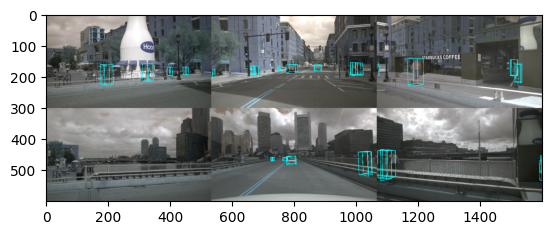

In [23]:
with torch.no_grad():
    for i, data in enumerate(data_loader):
        if i<=1:
            continue
            
        if i>=3:
            break
            
        # 入力データを過去と現在フレームに分ける(元のソフト)
        inputs = [d.cuda() for d in data['img_inputs'][0]]
        imgs, sensor2keyegos, ego2globals, intrins, post_rots, post_trans, bda, _ = model.prepare_inputs(inputs)
        
        img_curr, img_prev = imgs
        sensor2keyegos_curr, sensor2keyegos_prev = sensor2keyegos
        ego2globals_curr, ego2globals_prev = ego2globals
        intrins_curr, intrins_prev = intrins
        post_rots_curr, post_rots_prev = post_rots
        post_trans_curr, post_trans_prev = post_trans
    
        # 入力データを過去と現在フレームに分ける(ONNX)
        input_data = sample_generator.get_data_info(i)
    
        # 前処理
        input_data = image_pipline(input_data)
        imgs_curr2, sensor2keyegos_curr2, ego2globals_curr2, intrins_curr2, post_rots_curr2, post_trans_curr2, bda_curr2 = input_data["img_inputs_curr"]
        imgs_prev2, sensor2keyegos_prev2, ego2globals_prev2, intrins_prev2, post_rots_prev2, post_trans_prev2, bda_prev2 = input_data["img_inputs_prev"]
    
        # 確認
        #tensor_original_curr = (img_curr, sensor2keyegos_curr, ego2globals_curr, intrins_curr, post_rots_curr, post_trans_curr, bda)
        #tensor_original_prev = (img_prev, sensor2keyegos_prev, ego2globals_prev, intrins_prev, post_rots_prev, post_trans_prev, bda)
        #tensor_onnx_curr = (imgs_curr2, sensor2keyegos_curr2, ego2globals_curr2, intrins_curr2, post_rots_curr2, post_trans_curr2, bda_curr2)
        #tensor_onnx_prev = (imgs_prev2, sensor2keyegos_prev2, ego2globals_prev2, intrins_prev2, post_rots_prev2, post_trans_prev2, bda_prev2)
        #print("===check curr data===")
        #check_allclose(tensor_original_curr, tensor_onnx_curr)
        #print("===check prev data===")
        #check_allclose(tensor_original_prev, tensor_onnx_prev)
    
        # BEV特徴量の確認(現在)
        #inputs_curr = (img_curr, sensor2keyegos_curr, ego2globals_curr, intrins_curr, post_rots_curr, post_trans_curr, bda, None)
        #bev_feat_curr, _ = model.prepare_bev_feat(*inputs_curr)
        #np.savetxt(f"{i}_bev_feat_curr.txt", bev_feat_curr.cpu().numpy().reshape(-1))
        
        # BEV特徴量の作成(過去)
        # 過去→現在フレームの移動量を元に整列するので、過去フレームも現在フレーム基準の座標で作成する
        #inputs_prev = (img_prev, sensor2keyegos_curr, ego2globals_curr, intrins_prev, post_rots_prev, post_trans_prev, bda, None)
        #bev_feat_prev, _ = model.prepare_bev_feat(*inputs_prev)
        #np.savetxt(f"{i}_bev_feat_prev.txt", bev_feat_prev.cpu().numpy().reshape(-1))

        # BEV特徴量の作成(ONNX)
        # FastBEVモデルの入力データ作成
        # 現在フレームの入力データ
        img_curr = input_data["img_inputs_curr"][0]
        _, coors_img_curr, coors_depth_curr = onnx_input_builder.get_fastray_input(input_data["img_inputs_curr"]) # 事前計算済みの座標変換情報
        coors_img_curr, coors_depth_curr = coors_img_curr[0], coors_depth_curr[0]
        #print(type(img_curr), img_curr.dtype, img_curr.shape)
        #print(type(coors_img_curr), coors_img_curr.dtype, coors_img_curr.shape)
        
        # 過去フレームの入力データ
        img_prev = input_data["img_inputs_prev"][0]
        # align_after_view_transfromationの対応
        input_data["img_inputs_prev"][1] = input_data["img_inputs_curr"][1] # sensor2keyegos
        input_data["img_inputs_prev"][2] = input_data["img_inputs_curr"][2] # ego2global
        _, coors_img_prev, coors_depth_prev = onnx_input_builder.get_fastray_input(input_data["img_inputs_prev"]) # 事前計算済みの座標変換情報
        coors_img_prev, coors_depth_prev = coors_img_prev[0], coors_depth_prev[0]

        # BEV特徴量の作成
        bev_feat_curr_onnx = fastbev.run(
            ["bev_feat"],
            {
                "img": img_curr.squeeze(0).cpu().numpy().astype(np.float32),
                "coors_img": coors_img_curr.cpu().numpy().astype(np.int64),
                "coors_depth": coors_depth_curr.cpu().numpy().astype(np.int64),
            }
        )[0]
        
        #print(bev_feat_curr)
        
        bev_feat_prev_onnx = fastbev.run(
            ["bev_feat"],
            {
                "img": img_prev.squeeze(0).cpu().numpy().astype(np.float32),
                "coors_img": coors_img_prev.cpu().numpy().astype(np.int64),
                "coors_depth": coors_depth_prev.cpu().numpy().astype(np.int64),
            }
        )[0]

        # 後段の処理のために、一旦torchに戻す
        bev_feat_curr = torch.from_numpy(bev_feat_curr_onnx).cuda().float()
        bev_feat_prev = torch.from_numpy(bev_feat_prev_onnx).cuda().float()
        

        #print("===check curr data===")
        #check_allclose(inputs_curr[:-1], inputs_prev[:-1])
        #print("===check prev data===")
        #check_allclose(tensor_original_prev, tensor_onnx_prev)
    
        
        # BEVの結合
        model.grid = None
        bev_feat_list = [bev_feat_curr, bev_feat_prev]
        bev_feat_list[1] = model.shift_feature(bev_feat_list[1], [sensor2keyegos_curr, sensor2keyegos_prev], bda)
        bev_feats = torch.cat(bev_feat_list, dim=1)
        #x = model.bev_encoder(bev_feats)

        # debug
        #np.savetxt(f"{i}_x.txt", x.cpu().numpy().reshape(-1))
    
        # 物体認識
        #outs = model.pts_bbox_head([x])
        # 物体認識の実行
        outs = fastbev4d.run(
            None,
            {"bev_feats": bev_feats.detach().cpu().numpy()}
        )
        
        #cls_out  = outs['all_cls_scores'][-1]
        #bbox_out = outs['all_bbox_preds'][-1]

        cls_out  = outs[0]
        bbox_out = outs[1]

        # debug
        #np.savetxt(f"{i}_cls_out.txt", cls_out[0].cpu().numpy())
        #np.savetxt(f"{i}_bbox_out.txt", bbox_out[0].cpu().numpy())
    
        # 後処理
        outs = [torch.from_numpy(x).float() for x in outs]
        bboxes, scores, labels = bbox_decoder.get_bbox(outs)
        #bboxes, scores, labels = bbox_decoder.get_bbox([cls_out.cpu(), bbox_out.cpu()])

        # debug
        #np.savetxt(f"{i}_bboxes.txt", bboxes.tensor.numpy())
        #np.savetxt(f"{i}_scores.txt", scores.numpy().reshape(-1))
        #np.savetxt(f"{i}_labels.txt", labels.numpy().reshape(-1))
    
        # 可視化
        # nuscenesに座標変換
        nusc_results, nusc_annos = visualizer.format_bbox(bboxes, scores, labels, data_infos[i])

        # dump
        # 最終的な出力形式を作成
        nusc_submissions = {'results': nusc_annos}
        jsonfile_prefix = f"./results/{i}/all_onnx/"
        mmcv.mkdir_or_exist(jsonfile_prefix)
        res_path = osp.join(jsonfile_prefix, 'results_nusc.json')
        print('Results writes to', res_path)
        mmcv.dump(nusc_submissions, res_path)
        
        drawed_img = visualizer.draw_bbox(nusc_results, data_infos[i], i)
        
        plt.imshow(drawed_img)

In [18]:
print("bev_feat_prev:", bev_feat_list[1].device)
print("sensor2keyegos_curr:", sensor2keyegos_curr.device)
print("sensor2keyegos_prev:", sensor2keyegos_prev.device)
print("bda:", bda.device)

bev_feat_prev: cuda:0
sensor2keyegos_curr: cuda:0
sensor2keyegos_prev: cuda:0
bda: cuda:0


In [14]:
check_allclose(bev_feat_prev, torch.from_numpy(bev_feat_prev_onnx))

AssertionError: index=0, max_diff=0.14683914184570312, mean_diff=0.0013727829791605473

In [15]:
diff = (bev_feat_prev - torch.from_numpy(bev_feat_prev_onnx).to(bev_feat_prev.device)).abs()

print("max:", diff.max().item())
print("mean:", diff.mean().item())
print("p50:", diff.quantile(0.50).item())
print("p90:", diff.quantile(0.90).item())
print("p99:", diff.quantile(0.99).item())
print("p999:", diff.quantile(0.999).item())

max: 0.14683914184570312
mean: 0.0013727829791605473
p50: 0.00014353729784488678
p90: 0.003728151321411133
p99: 0.01761719584465027
p999: 0.0371929407119751


In [10]:
bev_feat_prev

tensor([[[[0.2380, 0.8318, 0.2655,  ..., 0.9556, 0.9276, 0.7224],
          [0.3439, 0.8213, 0.3175,  ..., 1.1407, 1.1048, 0.6792],
          [0.3340, 0.7798, 0.2190,  ..., 1.1541, 1.1157, 0.6811],
          ...,
          [0.2900, 1.6889, 1.0961,  ..., 1.1311, 1.1051, 0.6731],
          [0.1143, 1.0134, 1.0782,  ..., 1.0927, 1.0818, 0.6709],
          [0.2217, 0.6175, 0.4254,  ..., 0.4346, 0.4361, 0.0735]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.1566, 0.1503, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.2152, 0.3990,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.7679, 1.1411, 0.8778,  ..., 0.5677, 0.5386, 0.3571],
          [0.4285, 0.0815, 0.3135,  ..., 0.0000, 0.0000, 0.0000],
          [0.3813, 0.0702, 0.1262,  ..., 0

In [9]:
inp = bev_feats.detach().contiguous().float().cpu().numpy()
zero = np.zeros_like(inp)
rand = np.random.randn(*inp.shape).astype(np.float32)

outs_real = fastbev4d.run(None, {"bev_feats": inp})
outs_zero = fastbev4d.run(None, {"bev_feats": zero})
outs_rand = fastbev4d.run(None, {"bev_feats": rand})

print("cls real-zero diff:", np.abs(outs_real[0] - outs_zero[0]).max())
print("bbox real-zero diff:", np.abs(outs_real[1] - outs_zero[1]).max())
print("cls real-rand diff:", np.abs(outs_real[0] - outs_rand[0]).max())
print("bbox real-rand diff:", np.abs(outs_real[1] - outs_rand[1]).max())

ValueError: Required inputs (['bev_feat']) are missing from input feed (['bev_feats']).

rot: [-0.9687876119182126, -0.004506968075376869, -0.00792272203393983, 0.24772460658591755]
trans: [599.849775495386, 1647.6411294309523, 0.0]
rot_quaternion: -0.969 -0.005i -0.008j +0.248k
Results writes to ./results/0/onnx/results_nusc.json


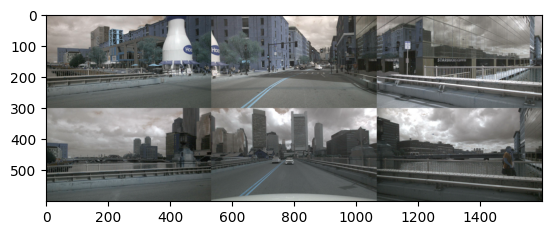

In [7]:
outputs = [torch.from_numpy(x).float() for x in outs]
bboxes, scores, labels = bbox_decoder.get_bbox(outputs)
# 可視化
# nuscenesに座標変換
nusc_results, nusc_annos = visualizer.format_bbox(bboxes, scores, labels, data_infos[i])

# dump
# 最終的な出力形式を作成
nusc_submissions = {
    'results': nusc_annos,
}
jsonfile_prefix = f"./results/{i}/onnx/"
mmcv.mkdir_or_exist(jsonfile_prefix)
res_path = osp.join(jsonfile_prefix, 'results_nusc.json')
print('Results writes to', res_path)
mmcv.dump(nusc_submissions, res_path)

drawed_img = visualizer.draw_bbox(nusc_results, data_infos[i], i)

plt.imshow(drawed_img)

In [8]:
outs

[array([[[-1.426011 , -2.3675284, -4.7901134, ..., -4.6579227,
          -2.8775046, -3.8359017],
         [-1.4317045, -2.339468 , -4.7084503, ..., -4.668589 ,
          -2.8853784, -3.7909093],
         [-1.5225428, -2.4050655, -4.755465 , ..., -5.1083245,
          -3.0519404, -3.8458574],
         ...,
         [-1.4139981, -2.3756094, -5.010217 , ..., -4.7846994,
          -2.9822478, -3.8918197],
         [-1.4138653, -2.357945 , -4.901741 , ..., -4.856145 ,
          -3.0105953, -3.804599 ],
         [-1.4533622, -2.3800955, -4.8256207, ..., -4.7949767,
          -2.9725573, -3.7803388]]], dtype=float32),
 array([[[ 3.9673367e+01,  2.9777843e+01,  1.5746284e+00, ...,
           1.5688187e-02,  1.9920863e-06,  1.2301340e-06],
         [ 3.2806271e+01,  2.9669888e+01,  1.5688189e+00, ...,
           1.4186649e-02,  2.0054624e-06,  1.2830541e-06],
         [ 1.2300121e+01,  1.9889221e+00,  1.4557300e+00, ...,
          -2.5890838e-02,  2.1687979e-06,  1.5888326e-06],
         ...,


In [22]:
outs = model.pts_bbox_head([x])

In [23]:
bbox_out2 = outs['all_bbox_preds'][-1]

In [24]:
bbox_out2

tensor([[[-1.0582e+01,  1.6629e+01, -3.5616e-01,  ..., -8.5421e-02,
          -2.4181e-06, -4.9061e-06],
         [ 2.9419e+01,  1.7579e+01, -3.0160e-01,  ...,  5.5703e-01,
           1.8400e-01, -2.7623e-02],
         [ 1.4205e+01,  9.1903e+00, -5.2790e-01,  ...,  9.9266e-01,
           8.7465e-01, -1.1111e-02],
         ...,
         [ 3.9806e+01, -2.3520e+01,  1.5047e+00,  ..., -9.5260e-02,
           7.7717e-03, -5.3144e-01],
         [ 3.0214e+01, -1.7664e+01,  1.5616e+00,  ..., -1.1011e-01,
           7.6174e-08, -4.8446e-07],
         [ 2.8684e+01,  1.5476e+01, -3.2082e-01,  ...,  6.0113e-01,
          -2.9922e-08, -5.5332e-06]]], device='cuda:0',
       grad_fn=<SelectBackward0>)

In [25]:
# 物体認識の実行
outs = fastbev4d.run(
    None,
    {"bev_feat": bev_feats.cpu().numpy()}
)

In [26]:
outs[1]

array([[[ 3.9673367e+01,  2.9777843e+01,  1.5746284e+00, ...,
          1.5688187e-02,  1.9920863e-06,  1.2301340e-06],
        [ 3.2806271e+01,  2.9669888e+01,  1.5688189e+00, ...,
          1.4186649e-02,  2.0054624e-06,  1.2830541e-06],
        [ 1.2300121e+01,  1.9889221e+00,  1.4557300e+00, ...,
         -2.5890838e-02,  2.1687979e-06,  1.5888326e-06],
        ...,
        [ 4.1537342e+01, -2.6698105e+01,  1.5776374e+00, ...,
         -1.0652000e-01,  1.6994019e-06,  1.0626101e-06],
        [ 3.1669544e+01, -2.4219822e+01,  1.5530559e+00, ...,
         -2.8546649e-01,  1.4625407e-06,  1.0362070e-06],
        [ 3.2897350e+01,  2.2706577e+01,  1.5527482e+00, ...,
          1.7004533e-02,  2.1398182e-06,  1.2531999e-06]]], dtype=float32)

In [15]:
bev_feats.shape

torch.Size([1, 160, 128, 128])

In [39]:
torch.save(x.detach().cpu(), f"{i}_x.pt")

In [35]:
np.savetxt(f"{0}_bboxes.txt", bboxes.tensor.numpy())

In [44]:
cls_out[0]

tensor([[-5.4767, -6.9120, -8.1374,  ..., -5.2882, -3.9680, -5.3082],
        [-4.4926, -5.8090, -7.4662,  ..., -4.1087, -1.8249, -5.1390],
        [-7.0858, -8.7953, -8.4100,  ..., -6.2918, -5.3396, -5.9792],
        ...,
        [-2.9587, -4.2419, -6.6656,  ..., -4.8394, -3.3310, -5.1445],
        [-2.2480, -4.2254, -7.0996,  ..., -5.5701, -3.7050, -5.7157],
        [-4.4256, -5.6912, -6.8385,  ..., -4.1650, -0.9623, -4.8408]],
       device='cuda:0')

In [14]:
data_infos[0]

{'token': '3e8750f331d7499e9b5123e9eb70f2e2',
 'scene_token': 'fcbccedd61424f1b85dcbf8f897f9754',
 'timestamp': 1533151603547590,
 'lidar_path': './data_nuscenes/nuscenes/samples/LIDAR_TOP/n008-2018-08-01-15-16-36-0400__LIDAR_TOP__1533151603547590.pcd.bin',
 'lidar2ego_translation': [0.985793, 0.0, 1.84019],
 'lidar2ego_rotation': [0.706749235646644,
  -0.015300993788500868,
  0.01739745181256607,
  -0.7070846669051719],
 'ego2global_translation': [600.1202137947669, 1647.490776275174, 0.0],
 'ego2global_rotation': [-0.968669701688471,
  -0.004043399262151301,
  -0.007666594265959211,
  0.24820129589817977],
 'cams': {'CAM_FRONT': {'data_path': './data_nuscenes/nuscenes/samples/CAM_FRONT/n008-2018-08-01-15-16-36-0400__CAM_FRONT__1533151603512404.jpg',
   'type': 'CAM_FRONT',
   'sample_data_token': '4f5e35aa6c6a426ca945e206fb2f4921',
   'sensor2ego_translation': [1.72200568478, 0.00475453292289, 1.49491291905],
   'sensor2ego_rotation': [0.5077241387638071,
    -0.4973392230703816,
   

In [4]:
#from mmcv.parallel import MMDataParallel, MMDistributedDataParallel
#from mmdet3d.models import (Base3DDetector, Base3DSegmentor,
#                            SingleStageMono3DDetector)
#model_wrap = MMDataParallel(model, device_ids=cfg.gpu_ids) # モデルを指定GPU上で実行できる形にする

#models_3d = (Base3DDetector, Base3DSegmentor, SingleStageMono3DDetector)
#isinstance(model_wrap.module, Base3DDetector)

#print(model_wrap.module)

# １サンプルでの確認

In [10]:
first_data = next(iter(data_loader))

print(first_data.keys())
print(type(first_data['img_inputs']))
print(len(first_data['img_inputs']))
print(type(first_data['img_inputs'][0]))
print(len(first_data['img_inputs'][0]))
print(first_data['img_inputs'][0][0].shape)

/home/kenta/fastbev/mmdet3d/datasets/pipelines/loading.py:1307: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1682343998658/work/torch/csrc/utils/tensor_new.cpp:245.)
  gt_boxes, gt_labels = torch.Tensor(gt_boxes), torch.tensor(gt_labels)
/home/kenta/fastbev/mmdet3d/datasets/pipelines/loading.py:1307: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1682343998658/work/torch/csrc/utils/tensor_new.cpp:245.)
  gt_boxes, gt_labels = torch.Tensor(gt_boxes), torch.tensor(gt_labels)
/home/kenta/fastbev/mmdet3d/datasets/pipelines/loading.py:1307: UserWarning: Creating a tensor from a list of numpy.ndarra

dict_keys(['img_metas', 'points', 'img_inputs'])
<class 'list'>
1
<class 'list'>
7
torch.Size([1, 12, 3, 256, 704])


In [11]:
# 入力データを過去と現在フレームに分ける
inputs = [d.cuda() for d in first_data['img_inputs'][0]]
imgs, sensor2keyegos, ego2globals, intrins, post_rots, post_trans, bda, _ = model.prepare_inputs(inputs)

img_curr, img_prev = imgs
sensor2keyegos_curr, sensor2keyegos_prev = sensor2keyegos
ego2globals_curr, ego2globals_prev = ego2globals
intrins_curr, intrins_prev = intrins
post_rots_curr, post_rots_prev = post_rots
post_trans_curr, post_trans_prev = post_trans

In [13]:
#len(imgs)
#imgs[0].shape

In [8]:
#x, _ = model.image_encoder(img_curr.cuda())
#inputs = [x, sensor2keyegos_curr.cuda(), ego2globals_curr.cuda(), intrins_curr.cuda(), post_rots_curr.cuda(), post_trans_curr.cuda(), bda.cuda()]
#_, pre_img_coors_list, pre_depth_coors_list = model.img_view_transformer.get_fastray_input(inputs)
#coors_img, coors_depth = pre_img_coors_list[0], pre_depth_coors_list[0]

In [9]:
#coors_img

In [10]:
#x.shape

In [11]:
#img_curr

In [14]:
# BEV特徴量の作成
inputs_curr = (img_curr, sensor2keyegos_curr, ego2globals_curr, intrins_curr, post_rots_curr, post_trans_curr, bda, None)
bev_feat_curr, _ = model.prepare_bev_feat(*inputs_curr)

# BEV特徴量の作成
inputs_prev = (img_prev, sensor2keyegos_prev, ego2globals_prev, intrins_prev, post_rots_prev, post_trans_prev, bda, None)
bev_feat_prev, _ = model.prepare_bev_feat(*inputs_prev)

use_depth True
img_coord:  [tensor([3081, 3037, 3037,  ...,    0,    0,    0], device='cuda:0')]
use_depth True


In [15]:
# BEVの結合
bev_feat_list = [bev_feat_curr, bev_feat_prev]
bev_feat_list[1] = model.shift_feature(bev_feat_list[1], [sensor2keyegos_curr, sensor2keyegos_prev], bda)
bev_feats = torch.cat(bev_feat_list, dim=1)

In [16]:
# 物体認識
x = model.bev_encoder(bev_feats)
outs = model.pts_bbox_head([x])

cls_out  = outs['all_cls_scores'][-1]
bbox_out = outs['all_bbox_preds'][-1]

In [24]:
#x

In [25]:
#cls_out

# 可視化と後処理のコードの整合性確認

In [18]:
# jsonファイルとconfigファイルの読み込み
json_file   = load_json(json_path)
data_config = load_config(config_path)

# sample Generator
data_infos = json_file['infos']
sample_generator = NuScenesSampleGenerator(data_infos=data_infos, num_adj_frame=1)

# モデルの後処理
post_center_range = data_config["bbox_decoder"]["post_center_range"]
max_num           = data_config["bbox_decoder"]["max_num"]
num_classes       = data_config["bbox_decoder"]["num_classes"]
score_threshold   = data_config["bbox_decoder"]["score_threshold"]
bbox_decoder = BboxDecoder(post_center_range, max_num, num_classes, None)

# 可視化
save_path   = data_config["visualizer"]["save_path"]
save_format = data_config["visualizer"]["save_format"]
save_prefix = data_config["visualizer"]["save_prefix"]
fps         = data_config["visualizer"]["fps"]
visualizer  = Visualizer(0.2, save_path, save_format, save_prefix, fps, scale_factor=3, color_map=(0, 255, 255))

In [19]:
# 後処理
bboxes, scores, labels = bbox_decoder.get_bbox([cls_out.cpu(), bbox_out.cpu()])

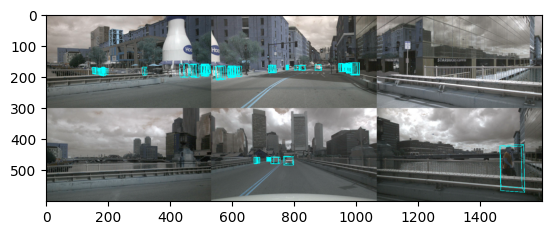

In [20]:
# 可視化
# nuscenesに座標変換
nusc_results = visualizer.format_bbox(bboxes, scores, labels, data_infos[0])

drawed_img = visualizer.draw_bbox(nusc_results, data_infos[0], 0)

plt.imshow(drawed_img)

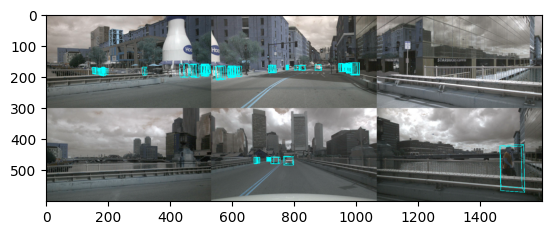

In [21]:
plt.imshow(drawed_img)

# 複数データで確認

/home/kenta/fastbev/mmdet3d/datasets/pipelines/loading.py:1307: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1682343998658/work/torch/csrc/utils/tensor_new.cpp:245.)
  gt_boxes, gt_labels = torch.Tensor(gt_boxes), torch.tensor(gt_labels)
/home/kenta/fastbev/mmdet3d/datasets/pipelines/loading.py:1307: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1682343998658/work/torch/csrc/utils/tensor_new.cpp:245.)
  gt_boxes, gt_labels = torch.Tensor(gt_boxes), torch.tensor(gt_labels)
/home/kenta/fastbev/mmdet3d/datasets/pipelines/loading.py:1307: UserWarning: Creating a tensor from a list of numpy.ndarra

use_depth True
use_depth True


/home/kenta/fastbev/model_deploy/bbox_decoder.py:160: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.post_center_range = torch.tensor(self.post_center_range, device=scores.device)


use_depth True
use_depth True


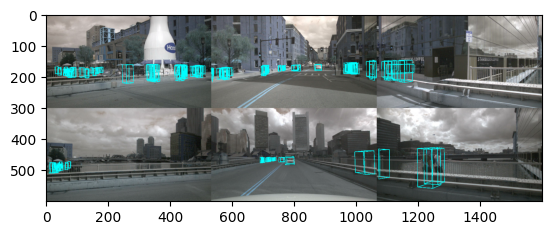

In [21]:
for i, data in enumerate(data_loader):
    if i>=2:
        break
        
    # 入力データを過去と現在フレームに分ける
    inputs = [d.cuda() for d in data['img_inputs'][0]]
    imgs, sensor2keyegos, ego2globals, intrins, post_rots, post_trans, bda, _ = model.prepare_inputs(inputs)
    
    img_curr, img_prev = imgs
    sensor2keyegos_curr, sensor2keyegos_prev = sensor2keyegos
    ego2globals_curr, ego2globals_prev = ego2globals
    intrins_curr, intrins_prev = intrins
    post_rots_curr, post_rots_prev = post_rots
    post_trans_curr, post_trans_prev = post_trans

    # BEV特徴量の作成
    inputs_curr = (img_curr, sensor2keyegos_curr, ego2globals_curr, intrins_curr, post_rots_curr, post_trans_curr, bda, None)
    bev_feat_curr, _ = model.prepare_bev_feat(*inputs_curr)
    
    # BEV特徴量の作成
    inputs_prev = (img_prev, sensor2keyegos_prev, ego2globals_prev, intrins_prev, post_rots_prev, post_trans_prev, bda, None)
    bev_feat_prev, _ = model.prepare_bev_feat(*inputs_prev)

    # BEVの結合
    bev_feat_list = [bev_feat_curr, bev_feat_prev]
    bev_feat_list[1] = model.shift_feature(bev_feat_list[1], [sensor2keyegos_curr, sensor2keyegos_prev], bda)
    bev_feats = torch.cat(bev_feat_list, dim=1)

    # 物体認識
    x = model.bev_encoder(bev_feats)
    outs = model.pts_bbox_head([x])
    
    cls_out  = outs['all_cls_scores'][-1]
    bbox_out = outs['all_bbox_preds'][-1]

    # 後処理
    bboxes, scores, labels = bbox_decoder.get_bbox([cls_out.cpu(), bbox_out.cpu()])

    # 可視化
    # nuscenesに座標変換
    nusc_results = visualizer.format_bbox(bboxes, scores, labels, data_infos[i])
    
    drawed_img = visualizer.draw_bbox(nusc_results, data_infos[i], i)
    
    plt.imshow(drawed_img)

In [23]:
nusc_results[99]

{'translation': [625.6761673434509, 1649.6340191864783, -0.8990358042437536],
 'size': [0.7220757007598877, 0.7416195273399353, 1.8766546249389648],
 'rotation': [-0.2788915045457838,
  -0.008250559540785967,
  0.003242262494523437,
  -0.9602817006969202],
 'detection_name': 'pedestrian',
 'detection_score': 0.17609117925167084}

In [12]:
# numpyに変換
boxes_np = bboxes.tensor.detach().numpy()
scores_np = scores.detach().numpy()
labels_np = labels.detach().numpy()

for bbox, score, label in zip(boxes_np, scores_np, labels_np):
    print(bbox)
    print(score)
    print(label)
    break

[-2.3364576e+01  3.7260437e+00  1.0645449e-02  4.6865883e+00
  2.0009577e+00  1.7836083e+00  3.1339781e+00 -1.2967285e+00
 -7.7674970e-02]
0.9832287
0


In [31]:
bboxes.tensor

tensor([[-2.3365e+01,  3.7260e+00,  1.0645e-02,  4.6866e+00,  2.0010e+00,
          1.7836e+00,  3.1340e+00, -1.2967e+00, -7.7675e-02],
        [ 3.3106e+01,  5.8204e+00, -4.1300e-01,  7.4608e-01,  6.8491e-01,
          1.8119e+00, -9.0568e-01,  5.5523e-01, -5.7454e-01],
        [ 2.1045e+01, -8.5424e+00, -1.4716e-01,  8.3264e-01,  7.7833e-01,
          1.8437e+00,  3.0110e+00, -1.3016e+00,  1.8549e-01],
        [-1.8939e+01,  5.8796e-02,  5.6634e-02,  4.7763e+00,  2.0521e+00,
          1.7833e+00,  6.7744e-03,  4.2543e+00,  1.1228e-01],
        [ 1.7754e+01,  1.1165e+01, -3.5354e-01,  8.2931e-01,  7.7189e-01,
          1.8309e+00,  3.0920e+00, -1.3450e+00,  5.9151e-02],
        [ 1.2517e+00, -6.5294e+00,  1.9062e-01,  8.9050e-01,  7.9393e-01,
          1.8621e+00, -4.5257e-02,  1.2190e+00, -9.3281e-02],
        [ 2.3290e+01,  1.1068e+01, -4.6458e-01,  7.4359e-01,  7.2733e-01,
          1.8324e+00,  3.0770e+00, -1.1516e+00,  5.3525e-02],
        [ 3.0981e+01, -9.6333e+00, -2.0356e-01, 

In [21]:
bboxes.tensor.shape

torch.Size([100, 9])

In [29]:
bbox_out

tensor([[[ 3.1958e+00,  1.6861e+01, -2.6704e-01,  ..., -2.9899e-01,
          -3.5440e-01, -4.8110e-03],
         [ 3.1022e+01,  1.8967e+01, -2.6753e-01,  ..., -7.6553e-02,
          -7.0961e-02, -4.0919e-01],
         [ 5.9439e+00,  5.3935e+00, -7.0211e-01,  ...,  9.1878e-01,
           1.0239e+00, -1.6799e-01],
         ...,
         [ 4.0901e+01, -1.8721e+01,  1.3858e+00,  ..., -1.2301e-01,
          -3.0106e-01, -6.5380e-02],
         [ 3.2685e+01, -1.5712e+01,  1.5434e+00,  ..., -1.0185e-01,
           1.2043e-02, -3.8065e-01],
         [ 3.0670e+01,  1.5350e+01, -3.6034e-01,  ..., -1.8978e-01,
          -4.1323e-06, -6.0432e-06]]], device='cuda:0',
       grad_fn=<SelectBackward0>)

In [42]:
bev_feat_prev

tensor([[[[0.3616, 0.8238, 0.6611,  ..., 0.9556, 0.9276, 0.7224],
          [0.5283, 0.8923, 0.5727,  ..., 1.1407, 1.1048, 0.6792],
          [0.5244, 0.8860, 0.5804,  ..., 1.1541, 1.1157, 0.6811],
          ...,
          [0.2793, 1.6608, 1.0972,  ..., 1.1311, 1.1051, 0.6731],
          [0.1209, 1.0008, 1.0710,  ..., 1.0927, 1.0818, 0.6709],
          [0.2227, 0.6196, 0.4292,  ..., 0.4346, 0.4361, 0.0735]],

         [[0.0000, 0.0172, 0.0000,  ..., 0.1566, 0.1503, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.1568, 0.2848,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.6861, 0.6720, 1.3193,  ..., 0.5677, 0.5386, 0.3571],
          [0.2347, 0.0312, 0.2217,  ..., 0.0000, 0.0000, 0.0000],
          [0.1780, 0.0300, 0.3004,  ..., 0

In [37]:
model.img_view_transformer.use_depth

True

In [38]:
print(bev_feat_curr)

tensor([[[[0.3616, 0.8238, 0.6611,  ..., 0.9556, 0.9276, 0.7224],
          [0.5283, 0.8923, 0.5727,  ..., 1.1407, 1.1048, 0.6792],
          [0.5244, 0.8860, 0.5804,  ..., 1.1541, 1.1157, 0.6811],
          ...,
          [0.2793, 1.6608, 1.0972,  ..., 1.1311, 1.1051, 0.6731],
          [0.1209, 1.0008, 1.0710,  ..., 1.0927, 1.0818, 0.6709],
          [0.2227, 0.6196, 0.4292,  ..., 0.4346, 0.4361, 0.0735]],

         [[0.0000, 0.0172, 0.0000,  ..., 0.1566, 0.1503, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.1568, 0.2848,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.6861, 0.6720, 1.3193,  ..., 0.5677, 0.5386, 0.3571],
          [0.2347, 0.0312, 0.2217,  ..., 0.0000, 0.0000, 0.0000],
          [0.1780, 0.0300, 0.3004,  ..., 0

In [28]:
with torch.no_grad():
    bev_feat_onnx = model(img_curr[0].cuda(), coors_img, coors_depth)
    print("PyTorch forward ok")
    print("bev_feat_pytorch =", bev_feat_onnx)

PyTorch forward ok
bev_feat_pytorch = tensor([[[[0.3616, 0.8238, 0.6611,  ..., 0.9556, 0.9276, 0.7224],
          [0.5283, 0.8923, 0.5727,  ..., 1.1407, 1.1048, 0.6792],
          [0.5244, 0.8860, 0.5804,  ..., 1.1541, 1.1157, 0.6811],
          ...,
          [0.2793, 1.6608, 1.0972,  ..., 1.1311, 1.1051, 0.6731],
          [0.1209, 1.0008, 1.0710,  ..., 1.0927, 1.0818, 0.6709],
          [0.2227, 0.6196, 0.4292,  ..., 0.4346, 0.4361, 0.0735]],

         [[0.0000, 0.0172, 0.0000,  ..., 0.1566, 0.1503, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.1568, 0.2848,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.6861, 0.6720, 1.3193,  ..., 0.5677, 0.5386, 0.3571],
          [0.2347, 0.0312, 0.2217,  ..., 0.0000, 0.0000, 0.0000],
    

# ONNXモデル

In [14]:
import numpy as np
import torch
import onnxruntime as ort
import torch.nn.functional as F

from nuscenes_sample_generator import NuScenesSampleGenerator
from img_pipeline import PrepareImageInputs
from onnx_input_builder import OnnxInputBuilder
from bbox_decoder import BboxDecoder
from visualizer import Visualizer 
from util import load_config, load_json

### 定数設定

In [15]:
# パスの設定
json_path   = "bevdetv3-nuscenes_infos_val.json"
config_path = "config.yaml"

### 初期化処理

In [16]:
# jsonファイルとconfigファイルの読み込み
json_file   = load_json(json_path)
data_config = load_config(config_path)

# sample Generator
data_infos = json_file['infos']
sample_generator = NuScenesSampleGenerator(data_infos=data_infos, num_adj_frame=1)

# image pipeline
image_pipline = PrepareImageInputs(data_config["data_config"], sequential=True, opencv_pp=False)

# 入力データの作成
grid_config = data_config["geometry"]["grid_config"]
image_size  = data_config["data_config"]["input_size"]
onnx_input_builder = OnnxInputBuilder(grid_config, image_size, stride=16, accelerate=True)

# モデルの後処理
post_center_range = data_config["bbox_decoder"]["post_center_range"]
max_num           = data_config["bbox_decoder"]["max_num"]
num_classes       = data_config["bbox_decoder"]["num_classes"]
score_threshold   = data_config["bbox_decoder"]["score_threshold"]
bbox_decoder = BboxDecoder(post_center_range, max_num, num_classes, None)

# 可視化
save_path   = data_config["visualizer"]["save_path"]
save_format = data_config["visualizer"]["save_format"]
save_prefix = data_config["visualizer"]["save_prefix"]
fps         = data_config["visualizer"]["fps"]
visualizer  = Visualizer(save_path, save_format, save_prefix, fps, scale_factor=3, color_map=(0, 255, 255))


# モデルの読み込み
fastbev = ort.InferenceSession(
    "./onnx/fastbev.onnx",
    #providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
    providers=["CPUExecutionProvider"]
)

fastbev4d = ort.InferenceSession(
    "./onnx/fastbev_4d.onnx",
    #providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
    providers=["CPUExecutionProvider"]
)

print("===fastbev===")
print("=== Inputs ===")
for i, x in enumerate(fastbev.get_inputs()):
    print(f"[{i}]")
    print(" name :", x.name)
    print(" shape:", x.shape)
    print(" type :", x.type)

print("\n=== Outputs ===")
for i, x in enumerate(fastbev.get_outputs()):
    print(f"[{i}]")
    print(" name :", x.name)
    print(" shape:", x.shape)
    print(" type :", x.type)

print("\n===fastbev4d===")
print("=== Inputs ===")
for i, x in enumerate(fastbev4d.get_inputs()):
    print(f"[{i}]")
    print(" name :", x.name)
    print(" shape:", x.shape)
    print(" type :", x.type)

print("\n=== Outputs ===")
for i, x in enumerate(fastbev4d.get_outputs()):
    print(f"[{i}]")
    print(" name :", x.name)
    print(" shape:", x.shape)
    print(" type :", x.type)

# warmup

===fastbev===
=== Inputs ===
[0]
 name : img
 shape: [6, 3, 256, 704]
 type : tensor(float)
[1]
 name : coors_img
 shape: [114688]
 type : tensor(int64)
[2]
 name : coors_depth
 shape: [114688]
 type : tensor(int64)

=== Outputs ===
[0]
 name : bev_feat
 shape: [1, 80, 128, 128]
 type : tensor(float)

===fastbev4d===
=== Inputs ===
[0]
 name : bev_feat
 shape: [1, 160, 128, 128]
 type : tensor(float)

=== Outputs ===
[0]
 name : all_cls_scores
 shape: [1, 300, 10]
 type : tensor(float)
[1]
 name : all_bbox_preds
 shape: [1, 300, 10]
 type : tensor(float)


In [17]:
bev_feats_np = bev_feats.detach().cpu().numpy().astype(np.float32)

# 物体認識の実行
outputs = fastbev4d.run(
    None,
    {"bev_feat": bev_feats_np}
)

all_cls_scores = outputs[0]
all_bbox_preds = outputs[1]

outputs = [torch.from_numpy(x).float() for x in outputs]

# 後処理
bboxes, scores, labels = bbox_decoder.get_bbox(outputs)

# 可視化
drawed_img = visualizer.draw_bbox(data_infos[0], bboxes, 0)

/home/kenta/fastbev/model_deploy/visualizer.py:103: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes_tensor = torch.tensor(bboxes)


In [18]:
all_cls_scores

array([[[-1.426011 , -2.3675284, -4.7901134, ..., -4.6579227,
         -2.8775046, -3.8359017],
        [-1.4317045, -2.339468 , -4.7084503, ..., -4.668589 ,
         -2.8853784, -3.7909093],
        [-1.5225428, -2.4050655, -4.755465 , ..., -5.1083245,
         -3.0519404, -3.8458574],
        ...,
        [-1.4139981, -2.3756094, -5.010217 , ..., -4.7846994,
         -2.9822478, -3.8918197],
        [-1.4138653, -2.357945 , -4.901741 , ..., -4.856145 ,
         -3.0105953, -3.804599 ],
        [-1.4533622, -2.3800955, -4.8256207, ..., -4.7949767,
         -2.9725573, -3.7803388]]], dtype=float32)

In [25]:
img_curr_np = img_curr.squeeze(0).detach().cpu().numpy().astype(np.float32)
coors_img_curr_np = coors_img.detach().cpu().numpy().astype(np.int64)
coors_depth_curr_np = coors_depth.detach().cpu().numpy().astype(np.int64)
bev_feat_curr = fastbev.run(
    ["bev_feat"],
    {
        "img": img_curr_np,
        "coors_img": coors_img_curr_np,
        "coors_depth": coors_depth_curr_np,
    }
)[0]

In [27]:
print("bev_feat_onnx =", bev_feat_curr)

bev_feat_onnx = [[[[0.36160713 0.8243552  0.66144705 ... 0.95520157 0.9272761
    0.7222681 ]
   [0.5283157  0.8928214  0.5744459  ... 1.1404402  1.1045437
    0.67910326]
   [0.5243599  0.8862259  0.5807485  ... 1.1538494  1.1155062
    0.6809729 ]
   ...
   [0.27931368 1.6613431  1.0969725  ... 1.1308484  1.1048677
    0.6730183 ]
   [0.12097833 1.000834   1.0705569  ... 1.092422   1.0815873
    0.67090756]
   [0.22272924 0.619456   0.42910117 ... 0.43430227 0.43579274
    0.07332185]]

  [[0.         0.01736683 0.         ... 0.15631777 0.14999151
    0.        ]
   [0.         0.         0.         ... 0.         0.
    0.        ]
   [0.         0.         0.         ... 0.         0.
    0.        ]
   ...
   [0.         0.1571477  0.2849682  ... 0.         0.
    0.        ]
   [0.         0.         0.         ... 0.         0.
    0.        ]
   [0.         0.         0.         ... 0.         0.
    0.        ]]

  [[0.68587583 0.67251617 1.3194002  ... 0.5681466  0.5389758
 

AttributeError: 'FastBEVTRT' object has no attribute 'module'

In [26]:
img_curr[0]

tensor([[[[ 0.3309,  0.3481,  0.3481,  ..., -1.7412, -1.7240, -1.7240],
          [ 0.2967,  0.3138,  0.3138,  ..., -1.5870, -1.6384, -1.6898],
          [ 0.3309,  0.3481,  0.3309,  ..., -1.4329, -1.4843, -1.6213],
          ...,
          [-0.8678, -0.8849, -0.8507,  ..., -1.0048, -1.0048, -1.0048],
          [-0.8164, -0.8507, -0.8335,  ..., -0.9877, -0.9363, -0.9705],
          [-0.8335, -0.8507, -0.8335,  ..., -0.9877, -0.9363, -0.9705]],

         [[ 0.2927,  0.3102,  0.3102,  ..., -1.4230, -1.4055, -1.4055],
          [ 0.2402,  0.2577,  0.2752,  ..., -1.2654, -1.3004, -1.3529],
          [ 0.2752,  0.2927,  0.2927,  ..., -1.1078, -1.1604, -1.3004],
          ...,
          [-0.7227, -0.7227, -0.7052,  ..., -0.8102, -0.7927, -0.7927],
          [-0.7402, -0.7752, -0.7402,  ..., -0.7577, -0.7752, -0.8102],
          [-0.7927, -0.7927, -0.7402,  ..., -0.7402, -0.7752, -0.8452]],

         [[ 0.4091,  0.4265,  0.4091,  ..., -1.2293, -1.2119, -1.2119],
          [ 0.3916,  0.4091,  

In [23]:
bev_feat.shape
bev_feat_onnx.shape

torch.Size([1, 80, 128, 128])

In [12]:
import numpy as np
import torch
import onnxruntime as ort
import torch.nn.functional as F

from nuscenes_sample_generator import NuScenesSampleGenerator
from img_pipeline import PrepareImageInputs
from onnx_input_builder import OnnxInputBuilder
from bbox_decoder import BboxDecoder
from visualizer import Visualizer 
from util import load_config, load_json

# パスの設定
json_path   = "bevdetv3-nuscenes_infos_val.json"
config_path = "config.yaml"

In [13]:
# jsonファイルとconfigファイルの読み込み
json_file   = load_json(json_path)
data_config = load_config(config_path)

# sample Generator
data_infos = json_file['infos']
sample_generator = NuScenesSampleGenerator(data_infos=data_infos, num_adj_frame=1)

# image pipeline
image_pipline = PrepareImageInputs(data_config["data_config"], sequential=True, opencv_pp=False)

# 入力データの作成
grid_config = data_config["geometry"]["grid_config"]
image_size  = data_config["data_config"]["input_size"]
onnx_input_builder = OnnxInputBuilder(grid_config, image_size, stride=16, accelerate=True)

In [14]:
inputs_cpu = [d.cpu() for d in inputs]
_, coors_img_curr, coors_depth_curr = onnx_input_builder.get_fastray_input(inputs_cpu)
coors_img_curr, coors_depth_curr = coors_img_curr[0], coors_depth_curr[0]

In [15]:
coors_img_curr

tensor([3081, 3037, 3037,  ...,    0,    0,    0])

In [39]:
# 1サンプルでの確認
input_data = sample_generator.get_data_info(0)

# 前処理
input_data = image_pipline(input_data)

# FastBEVモデルの入力データ作成
# 現在フレームの入力データ
img_curr = input_data["img_inputs_curr"][0]
_, coors_img_curr, coors_depth_curr = onnx_input_builder.get_fastray_input(input_data["img_inputs_curr"]) # 事前計算済みの座標変換情報
coors_img_curr, coors_depth_curr = coors_img_curr[0], coors_depth_curr[0]

In [16]:
coors_img_curr

tensor([3081, 3037, 3037,  ...,    0,    0,    0])

In [42]:
img_curr.shape

torch.Size([1, 6, 3, 256, 704])